# Poster Panel Examples

GHZ: 13 qubit with ibm_eagle_r3 18qubit comparison and 'panel' heatmap option 

DD 

In [1]:
# MUST run before importing matplotlib/noisiq plotting code.
# If this errors, run: %pip install ipympl
%matplotlib widget

In [2]:
# Notebook-local path setup and imports
#
# This cell does NOT import David_wip/examples/poster_panels/common.py.
# It only adds the local src/ directory when the notebook is somewhere inside
# the NoisiQ repository. If no repo root is found, it falls back to whatever
# noisiq package is already installed in the active environment.

from pathlib import Path
import sys
import inspect

def find_noisiq_repo_root(start: Path) -> Path | None:
    """Walk upward from the current working directory until src/noisiq is found."""
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / "src" / "noisiq").is_dir():
            return candidate
    return None


CWD = Path.cwd().resolve()
PROJECT_ROOT = find_noisiq_repo_root(CWD)

if PROJECT_ROOT is not None:
    SRC_DIR = PROJECT_ROOT / "src"
    if str(SRC_DIR) not in sys.path:
        sys.path.insert(0, str(SRC_DIR))
    print(f"Using local NoisiQ source from: {SRC_DIR}")
else:
    SRC_DIR = None
    print(
        "No local NoisiQ repo root found from the current working directory. "
        "Trying the installed noisiq package instead."
    )

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.transforms import offset_copy

try:
    import noisiq as nq
except ModuleNotFoundError as exc:
    raise RuntimeError(
        "Could not import noisiq. Run the notebook from somewhere inside the "
        "NoisiQ repo, or install the package into this environment with:\n\n"
        "    %pip install -e /path/to/NoisiQ\n"
    ) from exc

from noisiq.backends import ManyShotRunner, TrajectoryBackend
from noisiq.noise import fill_idle_with_identities
from noisiq.results.ghz_metrics import (
    ghz_state_fidelity,
    phased_ghz_state_fidelity,
    ghz_density_metric_bundle,
    ghz_subspace_population,
    ghz_branch_coherence_real,
)
from noisiq.visualization import interactive_heatmap, plot_error_heatmap
from noisiq.visualization.theme import (
    METRIC_BOX_ALPHA,
    METRIC_BOX_EDGE_COLOR,
    METRIC_BOX_FACE_COLOR,
    METRIC_BOX_FONT_FAMILY,
    METRIC_BOX_FONT_SIZE,
    METRIC_BOX_PAD,
    METRIC_BOX_TEXT_COLOR,
    METRIC_BOX_YOFFSET_PT,
    HEATMAP_SUPTITLE_FONT_SIZE,
    HEATMAP_SUPTITLE_Y,
)

print(f"CWD = {CWD}")
print(f"PROJECT_ROOT = {PROJECT_ROOT}")

Using local NoisiQ source from: /Users/davidsaxum/Desktop/Coding/NoisiQ/src
CWD = /Users/davidsaxum/Desktop/Coding/NoisiQ/notebooks
PROJECT_ROOT = /Users/davidsaxum/Desktop/Coding/NoisiQ


In [3]:
# User-tunable parameters
# Keep this small for notebook hover work. Increase only if your machine can handle the density matrix.
N_QUBITS = 13
PROFILE_NAME = "ibm_eagle_r3"
HARDWARE_GHZ_QUBITS = 18
SHOTS = 500
TRAJ_SHOTS = 200
SEED = 123

# "ghz_plus"  → (|00...0> + |11...1>) / sqrt(2)
# "ghz_minus" → (|00...0> - |11...1>) / sqrt(2)
TARGET_FOR_PANEL = "ghz_plus"

# Local preview position: right-aligned box, shifted slightly outside the axes.
# Source-level equivalent: set METRIC_BOX_X = 1.08 in src/noisiq/visualization/theme.py
METRIC_BOX_X_LOCAL = 1.08

In [4]:
# Small helpers

def _filtered_call(func, *args, **kwargs):
    """Call visualization functions while ignoring newer kwargs on older local code."""
    sig = inspect.signature(func)
    params = sig.parameters
    accepts_var_kwargs = any(p.kind == inspect.Parameter.VAR_KEYWORD for p in params.values())
    if not accepts_var_kwargs:
        kwargs = {k: v for k, v in kwargs.items() if k in params}
    return func(*args, **kwargs)


def hardware_ref_by_qubits(profile, n_qubits: int):
    """Return the exact GHZResult entry for n_qubits, not the closest-sized result."""
    for result in profile.ghz_results:
        if result.n_qubits == n_qubits and result.fidelity is not None:
            return result
    return None


def add_ghz_metric_box(ax, *, simulated_fidelity: float, hardware_fidelity: float | None):
    """Notebook-local metric box with exactly the two requested fidelity lines."""
    lines = [f"Simulated Fidelity = {simulated_fidelity:.4f}"]
    if hardware_fidelity is not None:
        lines.append(f"IBM_eagle_r3 (18q) Fidelity = {hardware_fidelity:.4f}")

    trans = offset_copy(
        ax.transAxes,
        fig=ax.get_figure(),
        x=0,
        y=-METRIC_BOX_YOFFSET_PT,
        units="points",
    )
    ax.text(
        METRIC_BOX_X_LOCAL,
        0.0,
        "\n".join(lines),
        transform=trans,
        ha="right",
        va="top",
        fontsize=METRIC_BOX_FONT_SIZE,
        family=METRIC_BOX_FONT_FAMILY,
        color=METRIC_BOX_TEXT_COLOR,
        clip_on=False,
        bbox={
            "boxstyle": f"round,pad={METRIC_BOX_PAD}",
            "facecolor": METRIC_BOX_FACE_COLOR,
            "edgecolor": METRIC_BOX_EDGE_COLOR,
            "alpha": METRIC_BOX_ALPHA,
        },
        zorder=1000,
    )

In [5]:
# Build GHZ circuit, hardware noise, aggregate heatmap data, and density-matrix fidelity

# --- Circuit builders ---
def build_ghz_plus_circuit(n_qubits: int, *, name: str | None = None) -> nq.Circuit:
    """Prepare |GHZ+> = (|00...0> + |11...1>) / sqrt(2)."""
    c = nq.Circuit(n_qubits=n_qubits, name=name or f"ghz_plus_{n_qubits}q")
    c.h(0, t=0)
    for i in range(n_qubits - 1):
        c.cnot(i, i + 1, t=i + 1)
    return c


def build_anti_ghz_circuit(n_qubits: int, *, name: str | None = None) -> nq.Circuit:
    """Prepare |GHZ-> = (|00...0> - |11...1>) / sqrt(2)."""
    c = build_ghz_plus_circuit(n_qubits, name=name or f"anti_ghz_minus_{n_qubits}q")
    c.z(0, t=n_qubits)
    return c


# --- Profile and hardware reference ---
profile = nq.noise.get_hardware(PROFILE_NAME)
hw_ref = hardware_ref_by_qubits(profile, HARDWARE_GHZ_QUBITS)
hw_fidelity = float(hw_ref.fidelity) if (hw_ref is not None and hw_ref.fidelity is not None) else None

# --- Target circuit selection ---
if TARGET_FOR_PANEL == "ghz_plus":
    raw_circuit = build_ghz_plus_circuit(N_QUBITS)
    phase_sign = +1
elif TARGET_FOR_PANEL == "ghz_minus":
    raw_circuit = build_anti_ghz_circuit(N_QUBITS)
    phase_sign = -1
else:
    raise ValueError("TARGET_FOR_PANEL must be 'ghz_plus' or 'ghz_minus'")

circuit = fill_idle_with_identities(raw_circuit, profile.gate_times)

# --- Noiseless reference (confirms the circuit prepares the correct target) ---
rho_ideal = TrajectoryBackend().run(
    raw_circuit,
    noise_model=None,
    n_shots=1,
    seed=SEED,
).final_state

if rho_ideal is None:
    raise RuntimeError("Noiseless TrajectoryBackend returned final_state=None.")

ideal_fidelity = phased_ghz_state_fidelity(rho_ideal, N_QUBITS, phase_sign=phase_sign).value
ideal_pop = ghz_subspace_population(rho_ideal, N_QUBITS).value
ideal_coh = ghz_branch_coherence_real(rho_ideal, N_QUBITS).value

print(f"Noiseless raw-circuit target fidelity = {ideal_fidelity:.6f}")
print(f"Noiseless GHZ-family subspace pop     = {ideal_pop:.6f}")
print(f"Noiseless Re branch coherence         = {ideal_coh:.6f}")
print(f"Raw circuit operation count           = {len(raw_circuit.operations)}")
print("Last few raw operations:")
for op in raw_circuit.operations[-5:]:
    print(" ", op)
print()

# --- Noisy simulation (needed by Cells 6 and 7) ---
noise_twirl = profile.to_noise_model(circuit, mode="t2", representation="pauli_twirl")
aggregate = ManyShotRunner().run(
    circuit,
    n_shots=SHOTS,
    noise_config=noise_twirl,
    seed=SEED,
)

noise_coherent = profile.to_noise_model(circuit, mode="t2", representation="coherent")
trajectory = TrajectoryBackend().run(
    circuit,
    noise_model=noise_coherent,
    n_shots=TRAJ_SHOTS,
    seed=SEED,
)
rho = trajectory.final_state
if rho is None:
    raise RuntimeError("TrajectoryBackend returned final_state=None; cannot compute density-matrix fidelity.")

fidelity_report = ghz_state_fidelity(
    rho,
    N_QUBITS,
    backend="TrajectoryBackend",
    noise_model=f"{profile.name}, coherent/T2 hardware-profile model",
)

print(f"Profile: {profile.name} ({profile.vendor} {profile.system})")
print(f"Reported profile T1 = {profile.t1 * 1e6:.0f} µs")
print(f"Reported profile T2 = {profile.t2 * 1e6:.0f} µs")
print(f"Simulated Fidelity = {fidelity_report.value:.4f}")
if hw_ref is not None:
    print(f"IBM_eagle_r3 ({hw_ref.n_qubits}q) Fidelity = {hw_fidelity:.4f}  [{hw_ref.source}, {hw_ref.year}]")
else:
    print(f"No exact {HARDWARE_GHZ_QUBITS}q GHZ hardware reference found on profile.")

Noiseless raw-circuit target fidelity = 1.000000
Noiseless GHZ-family subspace pop     = 1.000000
Noiseless Re branch coherence         = 0.500000
Raw circuit operation count           = 13
Last few raw operations:
  Operation(gate='CNOT', qubits=(7, 8), t=8)
  Operation(gate='CNOT', qubits=(8, 9), t=9)
  Operation(gate='CNOT', qubits=(9, 10), t=10)
  Operation(gate='CNOT', qubits=(10, 11), t=11)
  Operation(gate='CNOT', qubits=(11, 12), t=12)

Profile: ibm_eagle_r3 (IBM Eagle r3)
Reported profile T1 = 262 µs
Reported profile T2 = 177 µs
Simulated Fidelity = 0.7670
IBM_eagle_r3 (18q) Fidelity = 0.5165  [arXiv:1905.05720, 2019]


In [6]:
# Cell 5b — Noisy diagnostic bundle: breaks fidelity into its two additive components
#   F = 0.5 * subspace_population + branch_coherence_real
# Low subspace_population → population leaking out of |00...0⟩/|11...1⟩ (T1 / amplitude damping).
# Low branch_coherence_real → off-diagonal coherence killed by dephasing (T2).

bundle = ghz_density_metric_bundle(
    rho, N_QUBITS, phase_sign=phase_sign,
    backend="TrajectoryBackend",
    noise_model=f"{profile.name}, coherent/T2",
)
simulated_fidelity    = bundle["target_fidelity"].value
subspace_population   = bundle["subspace_population"].value
branch_coherence_real = bundle["branch_coherence_real"].value

print(f"Simulated Fidelity             = {simulated_fidelity:.4f}  (= 0.5·pop + Re·coh below)")
print(f"GHZ-family subspace population = {subspace_population:.4f}  (ideal = 1.0)")
print(f"Re branch coherence            = {branch_coherence_real:.4f}  (ideal = 0.5)")
print()
print(f"Cross-check vs fidelity_report : {fidelity_report.value:.4f}  (should match Simulated Fidelity)")

Simulated Fidelity             = 0.7670  (= 0.5·pop + Re·coh below)
GHZ-family subspace population = 0.9150  (ideal = 1.0)
Re branch coherence            = 0.3095  (ideal = 0.5)

Cross-check vs fidelity_report : 0.7670  (should match Simulated Fidelity)


In [7]:
# Cell 6 — Static heatmap preview with the cleaned metric box
plt.close("all")
fig = _filtered_call(
    plot_error_heatmap,
    aggregate,
    circuit,
    noise_config=noise_twirl,
    heat_scale="relative",
    show_qualitative_ticks=True,
    impact_metric="expected",
    finalize_layout=False,
)
ax = fig.axes[0]
add_ghz_metric_box(
    ax,
    simulated_fidelity=fidelity_report.value,
    hardware_fidelity=hw_fidelity,
)
fig.suptitle(
    f"NoisiQ {N_QUBITS}q GHZ — IBM Eagle r3 (ibm_eagle_r3)",
    y=HEATMAP_SUPTITLE_Y,
    fontsize=HEATMAP_SUPTITLE_FONT_SIZE,
)
fig.canvas.draw_idle()
plt.close(fig)

In [8]:
# Cell 7 — Live hover/click panel version

from IPython.display import display

plt.close("all")

with plt.ioff():
    hover_context = {
        "noise_model": {
            "source": profile.name,
            "vendor": profile.vendor,
            "system": profile.system,
            "mode": "t2",
            "representation": "pauli_twirl",
            "single_qubit_error": profile.single_qubit_error,
            "two_qubit_error": profile.two_qubit_error,
            "spam_error": profile.spam_error,
            "t1_us": profile.t1 * 1e6,
            "t2_us": profile.t2 * 1e6,
        },
        "run_metrics": {
            "simulated_fidelity": fidelity_report.value,
            "hardware_fidelity_18q": hw_fidelity,
            "aggregate_zero_error_fraction": aggregate.zero_error_fraction,
        },
    }

    handle = _filtered_call(
        interactive_heatmap,
        aggregate,
        circuit,
        noise_config=noise_twirl,
        display_mode="panel",
        title=f"GHZ hardware-profile hover heatmap — {N_QUBITS}q",
        hover_context=hover_context,
        impact_metric="expected",
    )

    add_ghz_metric_box(
        handle.figure.axes[0],
        simulated_fidelity=fidelity_report.value,
        hardware_fidelity=hw_fidelity,
    )

    handle.figure.subplots_adjust(bottom=0.30)
    handle.figure.canvas.draw_idle()



## Source-level changes to mirror this notebook

For the repo source, the minimal changes are:

1. In `theme.py`, move the right-aligned metric box rightward by changing `METRIC_BOX_X` from `0.99` to `1.08`.
2. In `drawer.py`, add optional label arguments to `add_metric_box()` so the GHZ script can print exact labels like `Simulated Fidelity` and `IBM_eagle_r3 (18q) Fidelity` without changing every other plot.
3. In `03_ghz_noisiq_vs_hardware_hover_revised.py`, use the exact 18-qubit Eagle r3 hardware GHZ entry instead of the closest-size entry, and pass only the two fidelity values into `add_metric_box()`.

The current script passes `t1_us=profile.t1 * 1e6` and `t2_us=profile.t2 * 1e6`, so its metric box currently reports `T1 idle = 262 µs` and `T2 idle = 177 µs`. Those lines are intentionally omitted here because the requested metric box should only contain the two fidelity lines.


### DD Examples 

small GHZ-storage-uncompute circuit directly in the notebook, then manually adds an XY-4 dynamical-decoupling version

In [9]:
# DD build parameters

from dataclasses import dataclass
from numpy.typing import NDArray

import dataclasses
import numpy as np
import matplotlib.pyplot as plt

import noisiq as nq
from noisiq.backends import AggregateResult, ManyShotRunner, TrajectoryBackend
from noisiq.ir.circuit import Operation
from noisiq.noise import fill_idle_with_identities
from noisiq.results.metrics import MetricReport
from noisiq.visualization import (
    interactive_heatmap,
    plot_error_heatmap,
    add_metric_box,
    add_purity_panel,
    per_qubit_purities,
)
from noisiq.visualization.density_matrix import (
    density_matrix_state_fidelity,
    global_purity,
)

DD_N_QUBITS = 4
DD_STORAGE_LAYERS = 12
DD_SHOTS = 300
DD_TRAJ_SHOTS = 200
DD_SEED = 42

base_profile_dd = nq.noise.get_hardware("ibm_eagle_r3")

# Teaching/demo profile: adds coherent idle-Z so DD has a visible refocusing job.
demo_profile_dd = dataclasses.replace(
    base_profile_dd,
    idle_coherent_epsilon=0.07,
)

print(f"DD profile: {demo_profile_dd.name}")
print(f"1Q error   = {demo_profile_dd.single_qubit_error:.2e}")
print(f"2Q error   = {demo_profile_dd.two_qubit_error:.2e}")
print(f"T1         = {demo_profile_dd.t1 * 1e6:.0f} µs")
print(f"T2         = {demo_profile_dd.t2 * 1e6:.0f} µs")
print(f"idle Z eps = {demo_profile_dd.idle_coherent_epsilon}")

DD profile: ibm_eagle_r3
1Q error   = 2.40e-04
2Q error   = 7.40e-03
T1         = 262 µs
T2         = 177 µs
idle Z eps = 0.07


In [10]:
# DD notebook-local helpers — replaces common.py utilities for this section

def ideal_zero_state(n_qubits: int) -> np.ndarray:
    """Return |00...0> as a statevector."""
    psi = np.zeros(1 << n_qubits, dtype=complex)
    psi[0] = 1.0
    return psi


def per_qubit_purity_payload(rho: np.ndarray, n_qubits: int) -> dict[str, float]:
    """Return per-qubit reduced-state purities as a simple dictionary."""
    return {
        f"q{q}": float(purity)
        for q, purity in enumerate(per_qubit_purities(rho, n_qubits))
    }


@dataclass
class DDNotebookRun:
    label: str
    circuit: nq.Circuit
    noise: dict
    aggregate: AggregateResult
    rho: NDArray[np.complex128]
    fidelity_report: MetricReport
    purity_report: MetricReport
    per_qubit_purities: dict[str, float]

In [11]:
# Direct notebook DD builders

DD_SEQUENCES = {
    "hahn": ["x"],
    "CPMG": ["x", "x"],
    "XY-4": ["x", "y", "x", "y"],
    "XY-8": ["x", "y", "x", "y", "y", "x", "y", "x"],
}

DD_SEQUENCE_LABELS = [
    ("baseline", "No DD"),
    ("XY-4", "XY-4"),
    ("XY-8", "XY-8"),
    ("hahn", "Hahn"),
    ("CPMG", "CPMG"),
]


def ideal_zero_state(n_qubits: int) -> np.ndarray:
    """Return |00...0> as a statevector."""
    psi = np.zeros(1 << n_qubits, dtype=complex)
    psi[0] = 1.0
    return psi


def per_qubit_purity_payload(rho: np.ndarray, n_qubits: int) -> dict[str, float]:
    """Return per-qubit reduced-state purities as a simple dictionary."""
    return {
        f"q{q}": float(purity)
        for q, purity in enumerate(per_qubit_purities(rho, n_qubits))
    }


@dataclass
class DDNotebookRun:
    label: str
    circuit: nq.Circuit
    noise: dict
    aggregate: AggregateResult
    rho: NDArray[np.complex128]
    fidelity_report: MetricReport
    purity_report: MetricReport
    per_qubit_purities: dict[str, float]


def build_sparse_ghz_storage_circuit(
    n_qubits: int,
    storage_layers: int,
    *,
    name: str = "dd_storage_baseline",
) -> nq.Circuit:
    """
    Build GHZ prep -> storage gap -> inverse GHZ.

    If the storage is clean, the inverse GHZ returns the state to |00...0>.
    """
    c = nq.Circuit(n_qubits=n_qubits, name=name)

    c.h(0, t=0)
    for q in range(n_qubits - 1):
        c.cnot(q, q + 1, t=q + 1)

    inverse_start = (n_qubits - 1) + storage_layers

    for offset, q in enumerate(reversed(range(n_qubits - 1))):
        c.cnot(q, q + 1, t=inverse_start + offset)

    c.h(0, t=inverse_start + n_qubits)

    return c


def apply_dd_local(
    circuit: nq.Circuit,
    *,
    sequence: str,
    idle_threshold: int,
) -> nq.Circuit:
    """
    Notebook-local DD insertion.

    This mirrors noisiq.suppression.apply_dd, but keeps the poster notebook
    self-contained and explicit.
    """
    if sequence not in DD_SEQUENCES:
        raise ValueError(
            f"Unknown DD sequence {sequence!r}. "
            f"Available: {sorted(DD_SEQUENCES)}"
        )

    pulses = DD_SEQUENCES[sequence]
    n_pulses = len(pulses)

    new_circuit = nq.Circuit(
        n_qubits=circuit.n_qubits,
        name=f"{circuit.name}_{sequence}",
    )

    # Copy original gates without moving them.
    for op in sorted(circuit.operations, key=lambda o: (o.t, o.qubits)):
        if isinstance(op, Operation):
            new_circuit.add_gate(op.gate, op.qubits, t=op.t)

    # Find active layers per qubit.
    qubit_active: dict[int, list[int]] = {q: [] for q in range(circuit.n_qubits)}
    for op in circuit.operations:
        if not isinstance(op, Operation):
            continue
        for q in op.qubits:
            qubit_active[q].append(op.t)

    # Insert pulses into bounded idle windows.
    for q in range(circuit.n_qubits):
        active_times = sorted(set(qubit_active[q]))

        if len(active_times) < 2:
            continue

        for t_prev, t_next in zip(active_times[:-1], active_times[1:]):
            window_len = t_next - t_prev - 1
            effective_threshold = max(idle_threshold, n_pulses)

            if window_len < effective_threshold:
                continue

            pulse_times = np.round(
                np.linspace(t_prev, t_next, n_pulses + 2)[1:-1]
            ).astype(int)

            for pulse_name, pulse_t in zip(pulses, pulse_times):
                if pulse_name == "x":
                    new_circuit.x(q, t=int(pulse_t))
                elif pulse_name == "y":
                    new_circuit.y(q, t=int(pulse_t))
                else:
                    raise ValueError(f"Unknown pulse {pulse_name!r}")

    return new_circuit


def build_sequence_circuit_local(
    base_sparse: nq.Circuit,
    sequence: str,
    profile,
) -> nq.Circuit:
    """
    Return idle-filled baseline or idle-filled DD circuit.

    This matches the script's five-sequence behavior, but stays notebook-local.
    """
    if sequence == "baseline":
        sparse = base_sparse
    else:
        threshold = {
            "hahn": 1,
            "CPMG": 2,
            "XY-4": 4,
            "XY-8": 8,
        }[sequence]

        sparse = apply_dd_local(
            base_sparse,
            sequence=sequence,
            idle_threshold=threshold,
        )

    return fill_idle_with_identities(sparse, profile.gate_times)

In [12]:
# Build and run all five DD cases

def run_one_dd_sequence(
    *,
    label: str,
    circuit: nq.Circuit,
    profile,
    shots: int,
    traj_shots: int,
    seed: int,
) -> DDNotebookRun:
    """Run aggregate Pauli-frame heatmap pass plus density-matrix metric pass."""
    noise = profile.to_noise_model(
        circuit,
        mode="t2",
        representation="pauli_twirl",
    )

    aggregate = ManyShotRunner().run(
        circuit,
        n_shots=shots,
        noise_config=noise,
        seed=seed,
    )

    trajectory = TrajectoryBackend().run(
        circuit,
        noise_model=noise,
        n_shots=traj_shots,
        seed=seed,
    )

    rho = trajectory.final_state
    if rho is None:
        raise RuntimeError("TrajectoryBackend returned final_state=None.")

    ideal = ideal_zero_state(circuit.n_qubits)

    fidelity = density_matrix_state_fidelity(
        ideal,
        rho,
        backend="TrajectoryBackend",
        noise_model="IBM Eagle r3 + quasi-static idle-Z demo, Pauli-twirled",
        target=f"returned |0...0> after GHZ storage/uncompute ({circuit.n_qubits}q)",
    )

    purity = global_purity(
        rho,
        backend="TrajectoryBackend",
        noise_model="IBM Eagle r3 + quasi-static idle-Z demo, Pauli-twirled",
    )

    return DDNotebookRun(
        label=label,
        circuit=circuit,
        noise=noise,
        aggregate=aggregate,
        rho=rho,
        fidelity_report=fidelity,
        purity_report=purity,
        per_qubit_purities=per_qubit_purity_payload(rho, circuit.n_qubits),
    )


base_sparse_dd = build_sparse_ghz_storage_circuit(
    DD_N_QUBITS,
    DD_STORAGE_LAYERS,
    name="dd_storage_base_sparse",
)

runs: list[DDNotebookRun] = []

for offset, (sequence, label) in enumerate(DD_SEQUENCE_LABELS):
    sequence_circuit = build_sequence_circuit_local(
        base_sparse_dd,
        sequence,
        demo_profile_dd,
    )

    run = run_one_dd_sequence(
        label=label,
        circuit=sequence_circuit,
        profile=demo_profile_dd,
        shots=DD_SHOTS,
        traj_shots=DD_TRAJ_SHOTS,
        seed=DD_SEED + offset,
    )

    runs.append(run)


print("Built DD runs:")
for run in runs:
    print(
        f"  {run.label:>8}: "
        f"ops={len(run.circuit.operations):4d}, "
        f"F={run.fidelity_report.value:.4f}, "
        f"Tr(rho^2)={run.purity_report.value:.4f}, "
        f"zero-error={run.aggregate.zero_error_fraction:.4f}"
    )

Built DD runs:
     No DD: ops=  74, F=0.6750, Tr(rho^2)=0.5399, zero-error=0.5167
      XY-4: ops=  74, F=0.7150, Tr(rho^2)=0.5491, zero-error=0.5633
      XY-8: ops=  74, F=0.7650, Tr(rho^2)=0.6316, zero-error=0.6300
      Hahn: ops=  74, F=0.6450, Tr(rho^2)=0.4937, zero-error=0.5467
      CPMG: ops=  74, F=0.6850, Tr(rho^2)=0.5452, zero-error=0.5367


In [13]:
# Choose which DD rows to show

poster_runs = runs[:2]      # No DD + XY-4
# poster_runs = runs[:3]    # No DD + XY-4 + XY-8
# poster_runs = runs        # all five: No DD, XY-4, XY-8, Hahn, CPMG

print("Showing:")
for run in poster_runs:
    print(f"  {run.label}")

Showing:
  No DD
  XY-4


/var/folders/p0/xdqq8k0s1w3797c00k062p8r0000gn/T/ipykernel_6054/507693953.py:44: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(h_pad=1.6)


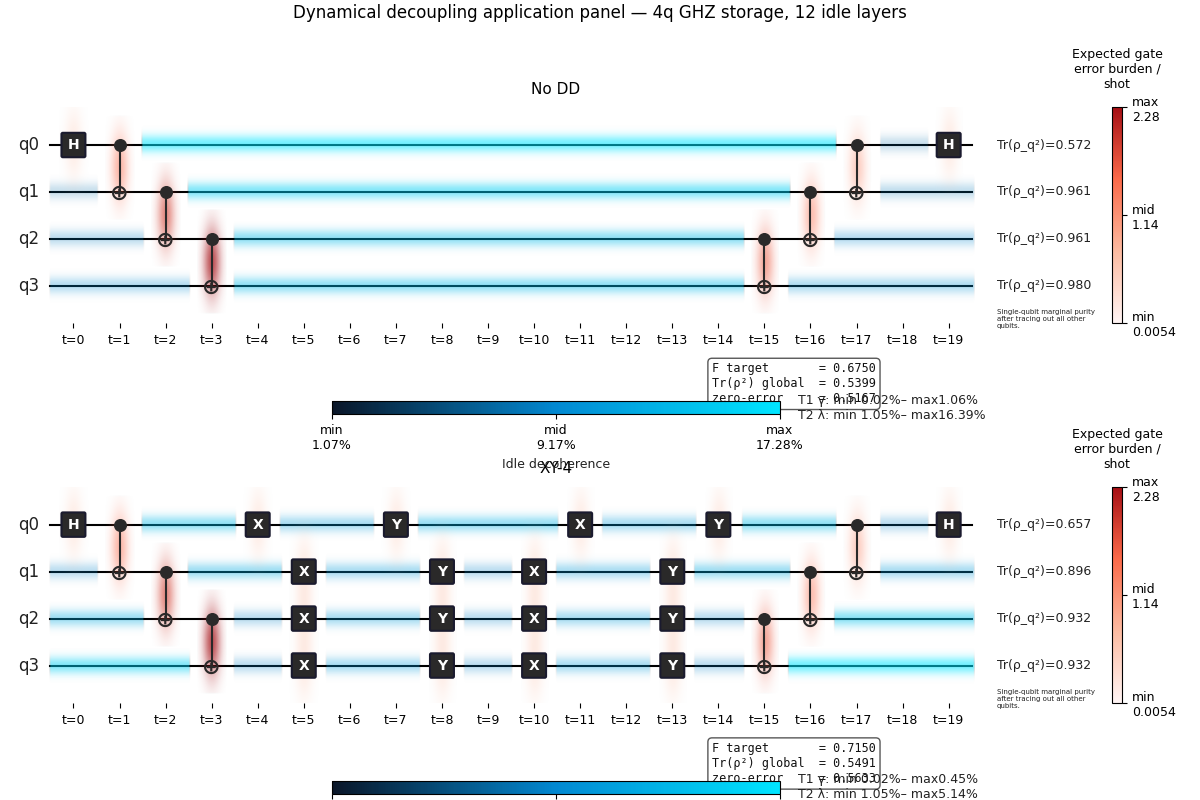

In [14]:
# Static DD heatmap panel

plt.close("all")

fig, axes = plt.subplots(
    len(poster_runs),
    1,
    figsize=(12, 4.0 * len(poster_runs)),
    squeeze=False,
)

for ax, run in zip(axes[:, 0], poster_runs):
    plot_error_heatmap(
        run.aggregate,
        run.circuit,
        noise_config=run.noise,
        title=run.label,
        ax=ax,
        heat_scale="relative",
        show_qualitative_ticks=True,
        finalize_layout=False,
    )

    add_metric_box(
        ax,
        fidelity=run.fidelity_report.value,
        global_purity=run.purity_report.value,
        zero_error=run.aggregate.zero_error_fraction,
    )

    add_purity_panel(
        fig,
        ax,
        run.rho,
        run.circuit.n_qubits,
    )

fig.suptitle(
    f"Dynamical decoupling application panel — "
    f"{DD_N_QUBITS}q GHZ storage, {DD_STORAGE_LAYERS} idle layers",
    y=0.995,
)

fig.tight_layout(h_pad=1.6)
plt.show()

<noisiq.visualization.charts.heatmap._attach_panel_hover.<locals>._Handle at 0x118f53b60>

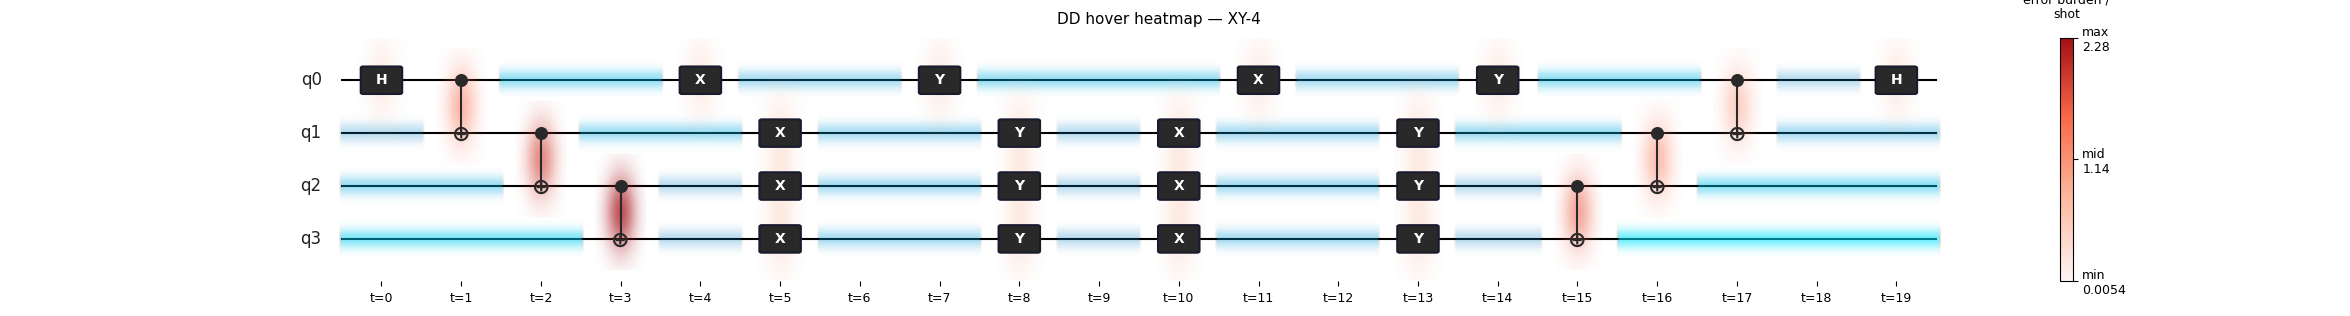

In [15]:
# Live interactive DD heatmap

plt.close("all")

DD_HOVER_LABEL = "XY-4"   # Change to: "No DD", "XY-4", "XY-8", "Hahn", or "CPMG"

hover_run = next(run for run in runs if run.label == DD_HOVER_LABEL)

hover_context_dd = {
    "noise_model": {
        "source": demo_profile_dd.name,
        "vendor": demo_profile_dd.vendor,
        "system": demo_profile_dd.system,
        "mode": "t2",
        "representation": "pauli_twirl",
        "single_qubit_error": demo_profile_dd.single_qubit_error,
        "two_qubit_error": demo_profile_dd.two_qubit_error,
        "spam_error": demo_profile_dd.spam_error,
        "t1_us": demo_profile_dd.t1 * 1e6,
        "t2_us": demo_profile_dd.t2 * 1e6,
        "idle_coherent_epsilon": demo_profile_dd.idle_coherent_epsilon,
    },
    "run_metrics": {
        "sequence": hover_run.label,
        "shots": hover_run.aggregate.n_shots,
        "zero_error_fraction": hover_run.aggregate.zero_error_fraction,
        "density_matrix_fidelity": hover_run.fidelity_report.value,
        "global_purity": hover_run.purity_report.value,
    },
}

interactive_heatmap(
    hover_run.aggregate,
    hover_run.circuit,
    noise_config=hover_run.noise,
    display_mode="panel",
    title=f"DD hover heatmap — {hover_run.label}",
    hover_context=hover_context_dd,
)



### MCM Bell Parity Check

In [16]:
# Bell parity-check imports

from dataclasses import dataclass
from typing import Iterable

import numpy as np
import matplotlib.pyplot as plt

import noisiq as nq

from noisiq.backends import ManyShotRunner, StimTableauBackend, TrajectoryBackend
from noisiq.ir.circuit import Operation
from noisiq.ir.classical import ConditionalOp, Measurement
from noisiq.noise import PauliError
from noisiq.results.metrics import MetricKind, MetricReport
from noisiq.visualization import (
    add_metric_box,
    draw_circuit_with_labels,
    interactive_heatmap,
    plot_error_heatmap,
    plot_qubit_error_bar,
    per_qubit_purities,
)
from noisiq.visualization.density_matrix import (
    density_matrix_state_fidelity,
    global_purity,
)
from noisiq.visualization.pauli_frame_tracker import build_modal_trajectory_frames

from IPython.display import display

In [17]:
# Bell parity-check parameters

BELL_SHOTS = 4096
BELL_TRAJ_SHOTS = 800
BELL_SEED = 7

# X-biased demo noise.
# This makes the parity-check example visually interpretable because the circuit
# is designed to catch/correct bit-flip parity changes.
BELL_P_1Q = 0.006
BELL_P_2Q = 0.014
BELL_P_IDLE = 0.001
BELL_X_BIAS = 0.85

BELL_NOISE_LABEL = "X-biased Pauli channel demo"

print(f"Bell shots       = {BELL_SHOTS}")
print(f"Trajectory shots = {BELL_TRAJ_SHOTS}")
print(f"p_1q             = {BELL_P_1Q}")
print(f"p_2q             = {BELL_P_2Q}")
print(f"p_idle           = {BELL_P_IDLE}")
print(f"X bias           = {BELL_X_BIAS}")

Bell shots       = 4096
Trajectory shots = 800
p_1q             = 0.006
p_2q             = 0.014
p_idle           = 0.001
X bias           = 0.85


In [18]:
# Direct Bell parity-check circuit builder

def build_bell_parity_check_circuit(
    *,
    final_measurements: bool = False,
) -> nq.Circuit:
    """
    Build a 3-qubit Bell parity-check circuit with one mid-circuit measurement.

    Qubits:
        q0, q1 : Bell-pair data qubits
        q2     : Z0Z1 parity ancilla

    Classical registers:
        syndrome[0] : parity-check result
        data[0:2]   : optional final q0/q1 measurement bits
    """
    c = nq.Circuit(n_qubits=3, name="bell_parity_repetition_check")
    syndrome = c.add_classical_register("syndrome", 1)

    # Bell preparation:
    # |Phi+> = (|00> + |11>) / sqrt(2)
    c.h(0, t=0)
    c.cnot(0, 1, t=1)

    # Z0Z1 parity measurement into ancilla q2.
    c.cnot(0, 2, t=2)
    c.cnot(1, 2, t=3)

    # Measure and reset the ancilla.
    c.measure(2, syndrome[0], reset=True, t=4)

    # Minimal correction:
    # If syndrome = 1, the data pair has odd Z-basis parity, so flip q1.
    c.c_if(syndrome[0], value=1).x(1, t=5)

    if final_measurements:
        data = c.add_classical_register("data", 2)
        c.measure(0, data[0], t=6)
        c.measure(1, data[1], t=6)

    return c


bell_state_circuit = build_bell_parity_check_circuit(final_measurements=False)
bell_measured_circuit = build_bell_parity_check_circuit(final_measurements=True)

print("State circuit operations:")
for idx, op in enumerate(bell_state_circuit.operations):
    print(f"  {idx:02d}: {op}")

print()
print("Measured circuit operations:")
for idx, op in enumerate(bell_measured_circuit.operations):
    print(f"  {idx:02d}: {op}")

State circuit operations:
  00: Operation(gate='H', qubits=(0,), t=0)
  01: Operation(gate='CNOT', qubits=(0, 1), t=1)
  02: Operation(gate='CNOT', qubits=(0, 2), t=2)
  03: Operation(gate='CNOT', qubits=(1, 2), t=3)
  04: Measurement(qubit=2, cbit=ClassicalBit(name='syndrome[0]', index=0), t=4, basis='Z', reset=True)
  05: ConditionalOp(inner=Operation(gate='X', qubits=(1,), t=5), condition=ClassicalBit(name='syndrome[0]', index=0), value=1)

Measured circuit operations:
  00: Operation(gate='H', qubits=(0,), t=0)
  01: Operation(gate='CNOT', qubits=(0, 1), t=1)
  02: Operation(gate='CNOT', qubits=(0, 2), t=2)
  03: Operation(gate='CNOT', qubits=(1, 2), t=3)
  04: Measurement(qubit=2, cbit=ClassicalBit(name='syndrome[0]', index=0), t=4, basis='Z', reset=True)
  05: ConditionalOp(inner=Operation(gate='X', qubits=(1,), t=5), condition=ClassicalBit(name='syndrome[0]', index=0), value=1)
  06: Measurement(qubit=0, cbit=ClassicalBit(name='data[0]', index=1), t=6, basis='Z', reset=False)
  

In [19]:
# Bell notebook-local helpers — replaces common.py helpers

def ideal_bell_with_reset_ancilla() -> np.ndarray:
    """
    Return |Phi+>_q0q1 ⊗ |0>_q2.

    NoisiQ's indexing convention treats q0 as the first tensor axis, so the
    nonzero basis states are |000> and |110>.
    """
    psi = np.zeros(8, dtype=complex)
    psi[int("000", 2)] = 1.0 / np.sqrt(2.0)
    psi[int("110", 2)] = 1.0 / np.sqrt(2.0)
    return psi


def per_qubit_purity_payload(rho: np.ndarray, n_qubits: int) -> dict[str, float]:
    """Return per-qubit reduced-state purities as a simple dictionary."""
    return {
        f"q{q}": float(purity)
        for q, purity in enumerate(per_qubit_purities(rho, n_qubits))
    }


def pauli_noise_for_ops(
    circuit,
    *,
    p_1q: float = 0.002,
    p_2q: float = 0.008,
    p_idle: float = 0.0005,
    x_bias: float = 0.80,
) -> dict[int, object]:
    """
    Build a simple X-biased Pauli noise dictionary.

    This is deliberately X-biased for the Bell/repetition example so the
    parity check has a visible, physically interpretable job. It is not meant
    to be a calibrated hardware model.
    """
    if not 0.0 <= x_bias <= 1.0:
        raise ValueError(f"x_bias must be in [0, 1], got {x_bias}")

    noise: dict[int, object] = {}

    for op_idx, op in enumerate(circuit.operations):
        if isinstance(op, Measurement):
            continue

        actual_op = op.inner if isinstance(op, ConditionalOp) else op

        if not isinstance(actual_op, Operation):
            continue

        if actual_op.gate.name.upper() == "IDLE":
            p_total = p_idle
        elif actual_op.gate.num_qubits == 1:
            p_total = p_1q
        else:
            p_total = p_2q

        p_x = p_total * x_bias
        p_y = p_total * (1.0 - x_bias) / 2.0
        p_z = p_total * (1.0 - x_bias) / 2.0

        noise[op_idx] = PauliError(
            p_x=p_x,
            p_y=p_y,
            p_z=p_z,
        )

    return noise


def measurement_success_probability(
    measurements: dict[str, list[int]] | None,
    data_names: Iterable[str],
    success_bitstrings: set[str],
) -> float:
    """
    Compute a final-output success probability from named classical measurement bits.

    For this Bell example, success means the final q0/q1 data bits are even parity:
    00 or 11.
    """
    if not measurements:
        return float("nan")

    names = list(data_names)
    n = len(measurements[names[0]])

    success = 0
    for shot_idx in range(n):
        bits = "".join(
            str(int(measurements[name][shot_idx]))
            for name in names
        )
        if bits in success_bitstrings:
            success += 1

    return success / n if n else float("nan")


def parity_success_report(
    success_probability: float,
    n_shots: int,
) -> MetricReport:
    """Return a MetricReport for final Bell even-parity success."""
    se = float(
        np.sqrt(success_probability * (1.0 - success_probability) / n_shots)
    )

    return MetricReport(
        name="Bell even-parity output success probability",
        kind=MetricKind.OUTPUT_SUCCESS_PROBABILITY,
        value=float(success_probability),
        uncertainty=se,
        n_shots=n_shots,
        backend="StimTableauBackend / ManyShotRunner",
        noise_model=BELL_NOISE_LABEL,
        method="final measurement filter: q0q1 ∈ {00, 11}",
        definition="Fraction of shots whose final Bell data bits remain in the even-parity subspace",
        assumptions=(
            "This checks bit-flip parity protection only; it is not a full Bell-state fidelity.",
        ),
        limitations=(
            "Phase errors are mostly invisible to this Z-basis parity success metric.",
            "Use the density-matrix fidelity report for the small-system state-fidelity estimate.",
        ),
        target="Bell |Phi+> data state with reset ancilla",
    )

In [20]:
# Run Bell parity-check simulations

bell_noise_state = pauli_noise_for_ops(
    bell_state_circuit,
    p_1q=BELL_P_1Q,
    p_2q=BELL_P_2Q,
    p_idle=BELL_P_IDLE,
    x_bias=BELL_X_BIAS,
)

bell_noise_measured = pauli_noise_for_ops(
    bell_measured_circuit,
    p_1q=BELL_P_1Q,
    p_2q=BELL_P_2Q,
    p_idle=BELL_P_IDLE,
    x_bias=BELL_X_BIAS,
)

bell_runner = ManyShotRunner(StimTableauBackend())

bell_aggregate = bell_runner.run(
    bell_state_circuit,
    n_shots=BELL_SHOTS,
    noise_config=bell_noise_state,
    seed=BELL_SEED,
)

bell_measured = bell_runner.run(
    bell_measured_circuit,
    n_shots=BELL_SHOTS,
    noise_config=bell_noise_measured,
    seed=BELL_SEED + 1,
)

# Exact small-system density-matrix metrics under the same Pauli channel.
bell_traj = TrajectoryBackend().run_aggregate(
    bell_state_circuit,
    noise_model=bell_noise_state,
    n_shots=BELL_TRAJ_SHOTS,
    seed=BELL_SEED,
)

bell_rho = bell_traj.final_state
if bell_rho is None:
    raise RuntimeError("TrajectoryBackend returned final_state=None.")

bell_ideal = ideal_bell_with_reset_ancilla()

bell_fidelity = density_matrix_state_fidelity(
    bell_ideal,
    bell_rho,
    backend="TrajectoryBackend",
    noise_model=BELL_NOISE_LABEL,
    target="|Phi+>_q0q1 ⊗ |0>_q2",
)

bell_purity = global_purity(
    bell_rho,
    backend="TrajectoryBackend",
    noise_model=BELL_NOISE_LABEL,
)

bell_zero_error = bell_aggregate.zero_error_fraction_report(
    backend="StimTableauBackend / ManyShotRunner",
    noise_model=BELL_NOISE_LABEL,
)

bell_even_parity_success = measurement_success_probability(
    bell_measured.measurements,
    data_names=["data[0]", "data[1]"],
    success_bitstrings={"00", "11"},
)

bell_parity_report = parity_success_report(
    bell_even_parity_success,
    bell_measured.n_shots,
)

bell_per_qubit_purities = per_qubit_purity_payload(
    bell_rho,
    bell_state_circuit.n_qubits,
)

print("Bell parity-check metrics:")
print(f"  density-matrix Bell fidelity : {bell_fidelity.value:.4f}")
print(f"  global purity Tr(rho^2)      : {bell_purity.value:.4f}")
print(f"  zero-error fraction          : {bell_zero_error.value:.4f}")
print(f"  even-parity output success   : {bell_parity_report.value:.4f}")
print()
print("Per-qubit marginal purities:")
for q, purity in bell_per_qubit_purities.items():
    print(f"  {q}: {purity:.4f}")

Bell parity-check metrics:
  density-matrix Bell fidelity : 0.9400
  global purity Tr(rho^2)      : 0.8855
  zero-error fraction          : 0.9148
  even-parity output success   : 0.9565

Per-qubit marginal purities:
  q0: 0.5000
  q1: 0.5000
  q2: 1.0000


In [21]:
# Bell film-strip helper

def build_bell_filmstrip(
    circuit,
    result,
    *,
    max_frames: int = 6,
):
    """Draw selected modal Pauli-frame snapshots as a poster film strip."""
    frames = build_modal_trajectory_frames(circuit, result)
    layers = sorted(frames)

    if len(layers) > max_frames:
        idx = np.linspace(0, len(layers) - 1, max_frames).round().astype(int)
        layers = [layers[i] for i in idx]

    fig, axes = plt.subplots(
        len(layers),
        1,
        figsize=(13.5, 2.05 * len(layers)),
        squeeze=False,
    )

    for ax, t in zip(axes[:, 0], layers):
        frame = frames[t]
        draw_circuit_with_labels(
            ax,
            circuit,
            pauli_frame=frame,
            highlight_t=t,
            note=(
                f"Modal Pauli-frame snapshot after layer t={t}: "
                f"{frame.get_pauli_string()}"
            ),
        )

    fig.suptitle(
        "Bell parity-check film strip — dominant sampled Pauli error propagated through the circuit",
        y=1.01,
    )

    fig.tight_layout()
    return fig

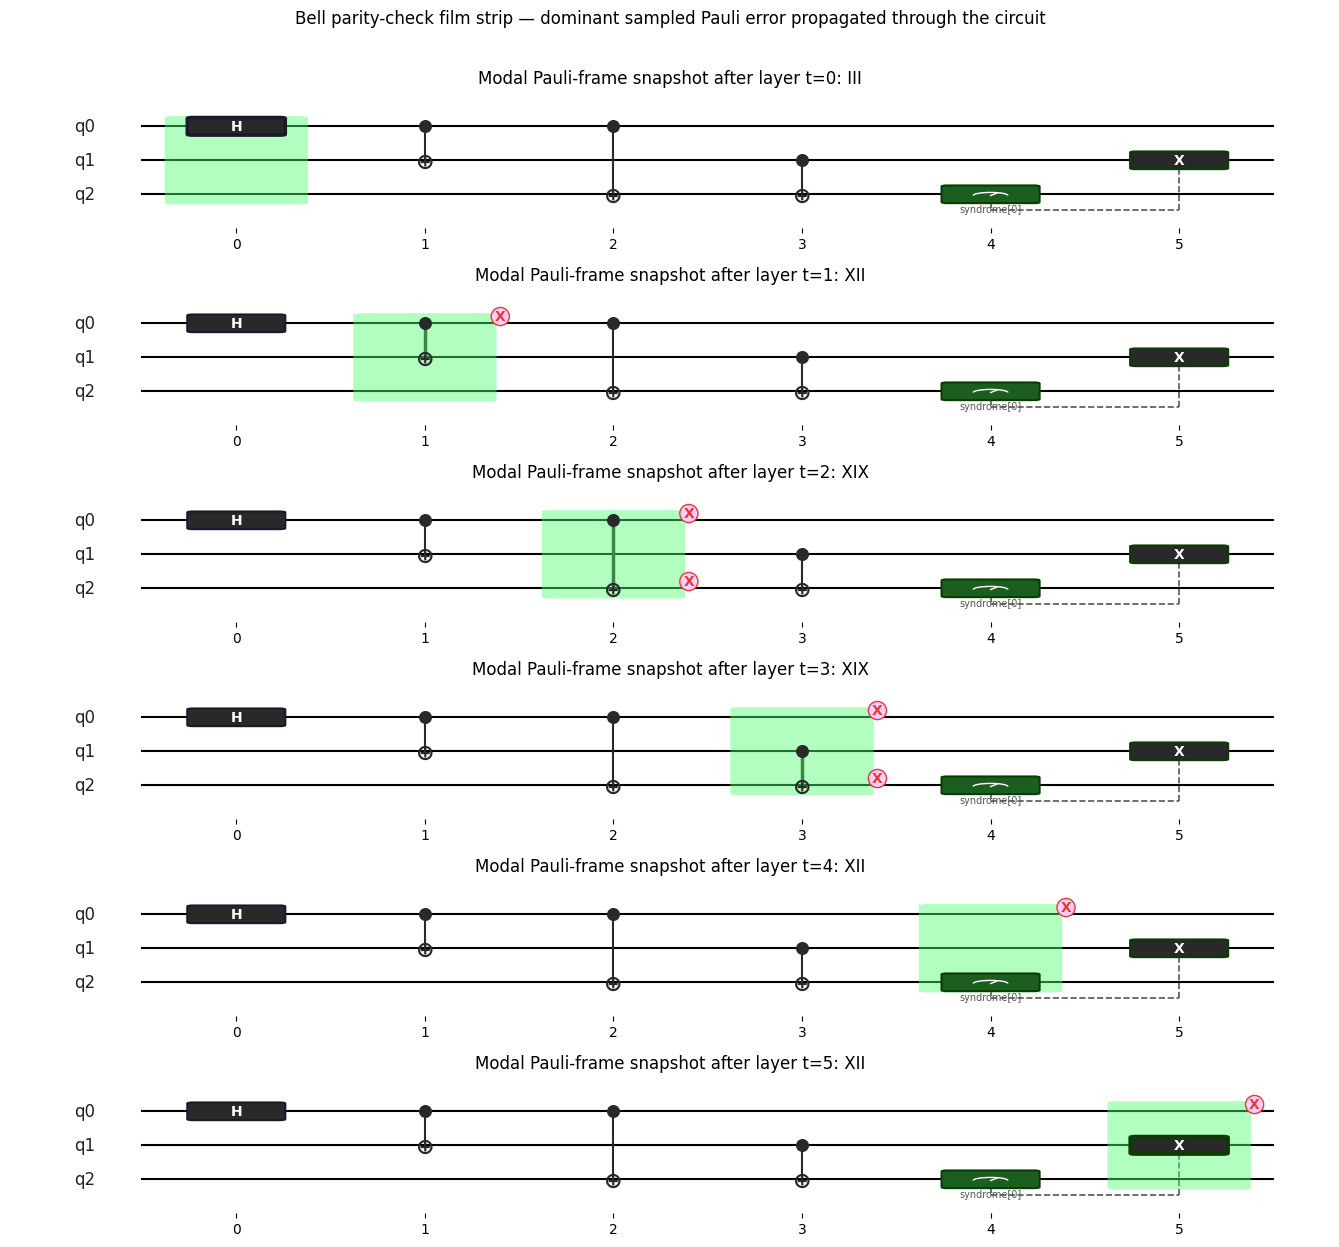

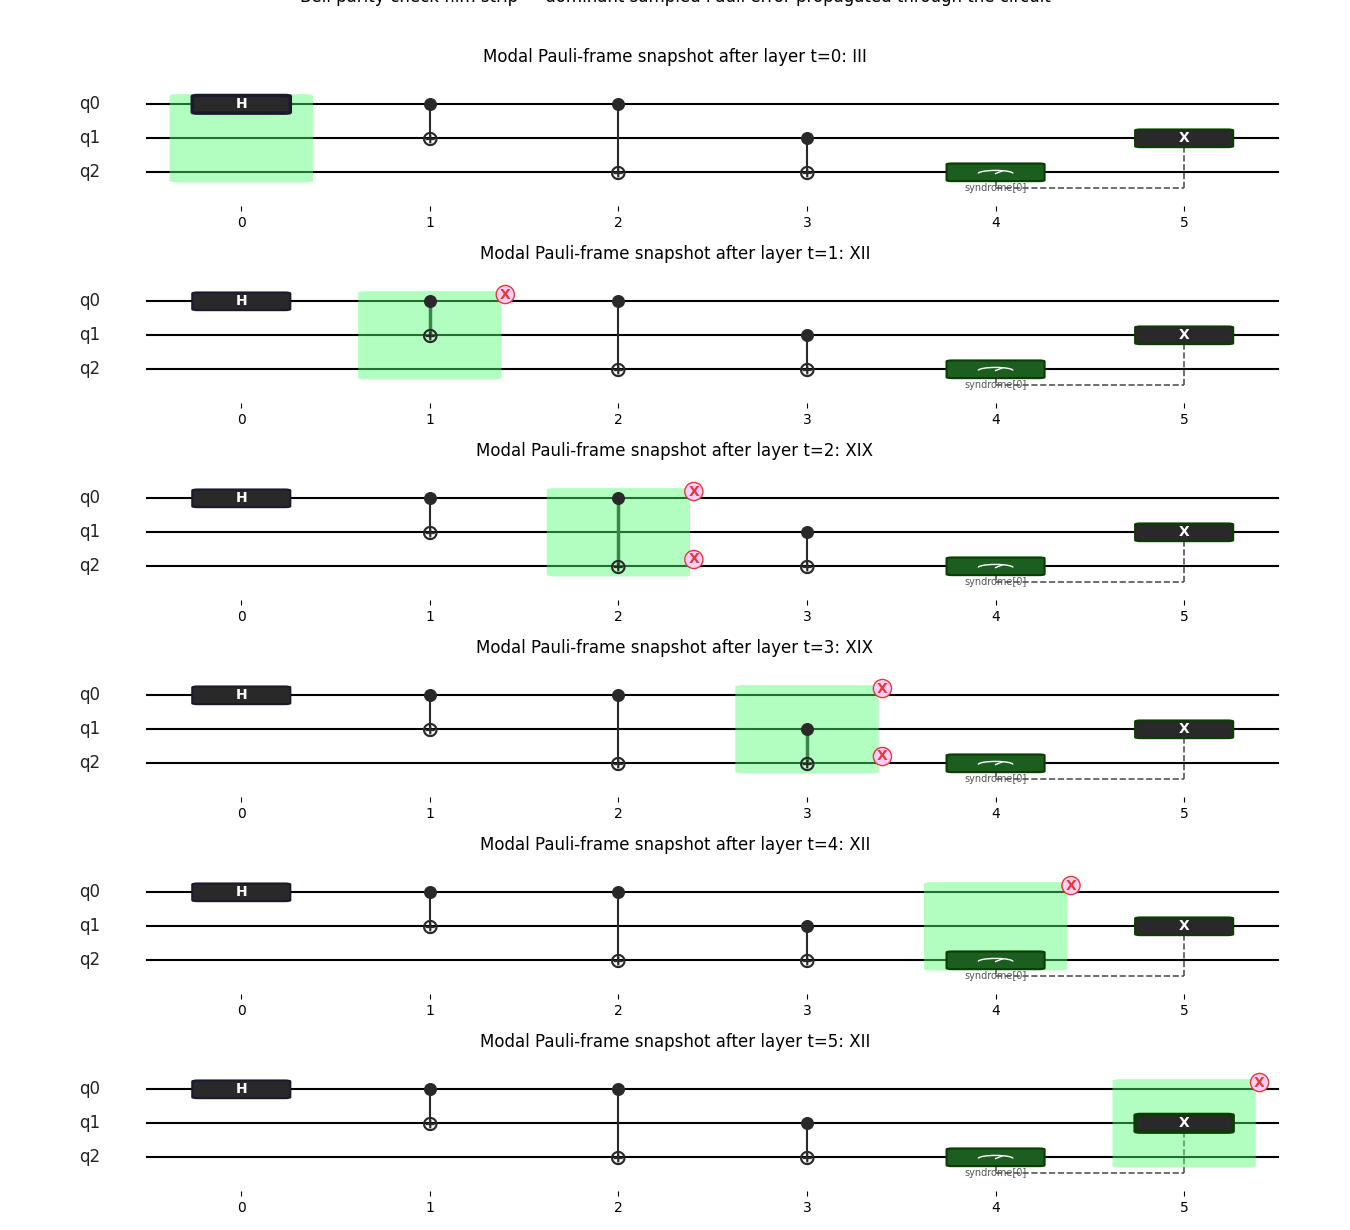

In [22]:
# Bell film strip

plt.close("all")

bell_film_fig = build_bell_filmstrip(
    bell_state_circuit,
    bell_aggregate,
    max_frames=6,
)

display(bell_film_fig)

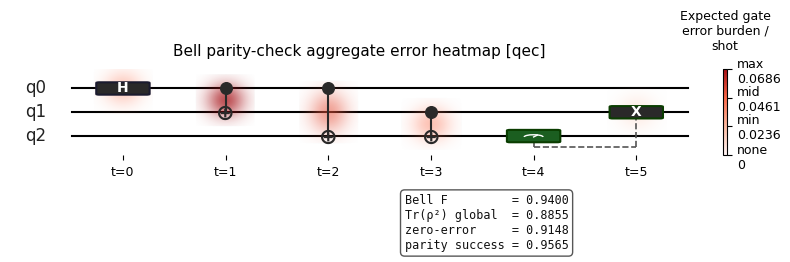

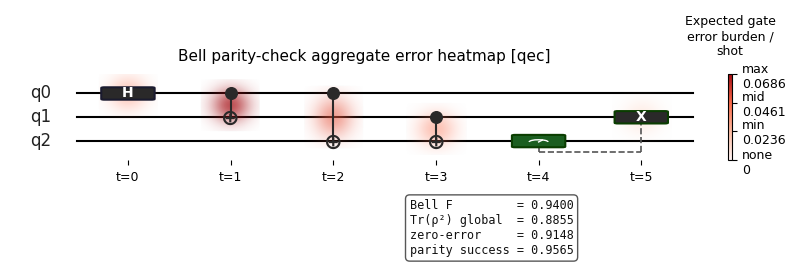

In [23]:
# Bell aggregate error heatmap

plt.close("all")

bell_heat_fig = plot_error_heatmap(
    bell_aggregate,
    bell_state_circuit,
    noise_config=bell_noise_state,
    title="Bell parity-check aggregate error heatmap",
    heat_scale="relative",
    show_qualitative_ticks=True,
    mcm_mode="qec",
    impact_metric="expected",
    finalize_layout=False,
)

bell_heat_ax = bell_heat_fig.axes[0]

add_metric_box(
    bell_heat_ax,
    fidelity=bell_fidelity.value,
    global_purity=bell_purity.value,
    zero_error=bell_zero_error.value,
    output_success=bell_parity_report.value,
    fidelity_label="Bell F",
)

bell_heat_fig.tight_layout()
display(bell_heat_fig)

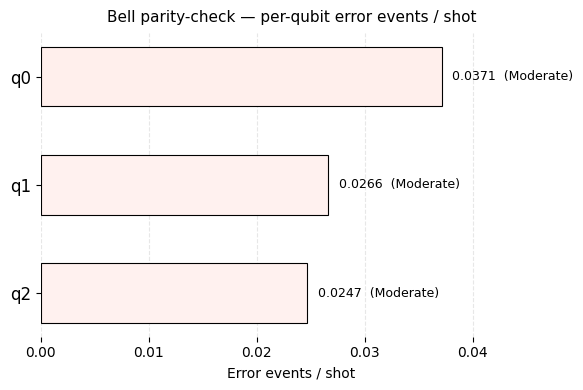

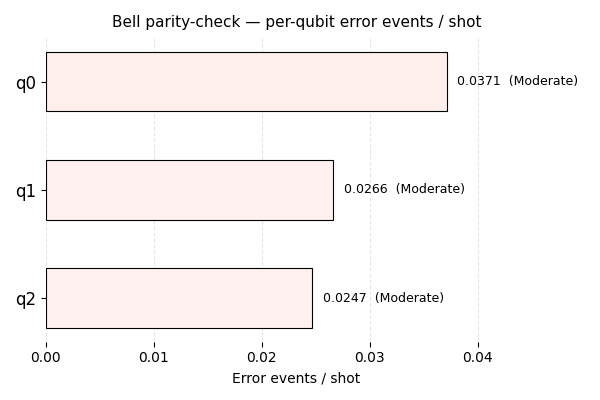

In [24]:
# Bell per-qubit error burden bar chart

plt.close("all")

bell_bar_fig = plot_qubit_error_bar(
    bell_aggregate,
    title="Bell parity-check — per-qubit error events / shot",
    color_scale="absolute",
    vmax=1.0,
    show_qualitative_labels=True,
)

display(bell_bar_fig)

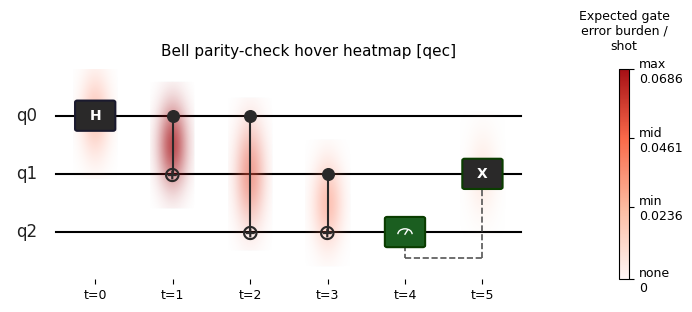

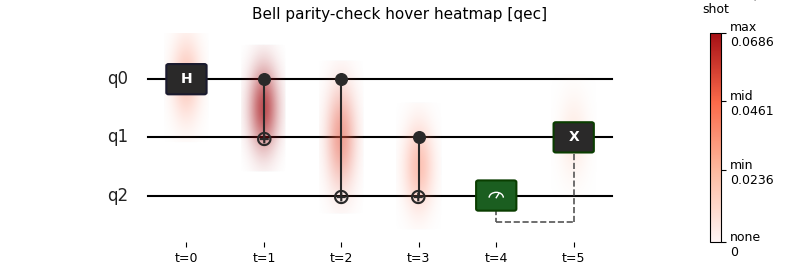

In [25]:
# Bell live hover/click panel

plt.close("all")

bell_hover_context = {
    "noise_model": {
        "source": BELL_NOISE_LABEL,
        "representation": "PauliError per operation",
        "p_1q": BELL_P_1Q,
        "p_2q": BELL_P_2Q,
        "p_idle": BELL_P_IDLE,
        "x_bias": BELL_X_BIAS,
        "p_y_fraction": (1.0 - BELL_X_BIAS) / 2.0,
        "p_z_fraction": (1.0 - BELL_X_BIAS) / 2.0,
    },
    "run_metrics": {
        "shots": bell_aggregate.n_shots,
        "trajectory_shots": BELL_TRAJ_SHOTS,
        "density_matrix_bell_fidelity": bell_fidelity.value,
        "global_purity": bell_purity.value,
        "zero_error_fraction": bell_zero_error.value,
        "even_parity_output_success": bell_parity_report.value,
    },
    "physics_note": {
        "correction": "If syndrome[0] = 1, apply X(q1).",
        "scope": "Bit-flip parity repair only; not full Bell-state QEC.",
    },
}

bell_hover = interactive_heatmap(
    bell_aggregate,
    bell_state_circuit,
    noise_config=bell_noise_state,
    display_mode="panel",
    title="Bell parity-check hover heatmap",
    hover_context=bell_hover_context,
    mcm_mode="qec",
    impact_metric="expected",
)

display(bell_hover.figure)